# Uncertainty Quantification and Calibration Analysis

This notebook evaluates the uncertainty quantification capabilities of MetaGNN using Monte Carlo (MC) Dropout and compares calibration with Gaussian Process (GP) baselines. We examine prediction confidence, calibration metrics, and transfer learning efficiency.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
import seaborn as sns

# Set matplotlib style for publication quality
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 10
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['savefig.dpi'] = 150

# Color scheme
colors = {
    'MetaGNN': '#2E75B6',
    'GIMME': '#A5A5A5',
    'iMAT': '#9DC3E6',
    'CORDA': '#BDD7EE',
    'tINIT': '#70AD47'
}

# Define paths
results_dir = Path('../results')
uncertainty_dir = results_dir / 'uncertainty_calibration'
predictions_dir = results_dir / 'per_patient_predictions'
stats_dir = results_dir / 'statistical_tests'

print(f"Loading data from uncertainty and predictions directories")

Loading data from uncertainty and predictions directories


## Load Calibration Data

Load reliability diagrams and ECE (Expected Calibration Error) computations.

In [2]:
# Load calibration data
calibration_data = pd.read_csv(uncertainty_dir / 'calibration_data.csv')
gp_baseline_calibration = pd.read_csv(uncertainty_dir / 'gp_baseline_calibration.csv')
ece_computation = pd.read_csv(uncertainty_dir / 'ece_computation.csv')

print("MetaGNN Calibration Data:")
print(calibration_data.head(10))
print(f"Shape: {calibration_data.shape}")

print("\nGP Baseline Calibration Data:")
print(gp_baseline_calibration.head(10))
print(f"Shape: {gp_baseline_calibration.shape}")

print("\nECE Computation:")
print(ece_computation)

MetaGNN Calibration Data:
   bin_midpoint  predicted_prob  observed_freq  bin_count
0          0.05            0.05       0.065868         95
1          0.15            0.15       0.146245        112
2          0.25            0.25       0.280251        136
3          0.35            0.35       0.366599         93
4          0.45            0.45       0.457969         95
5          0.55            0.55       0.555319        135
6          0.65            0.65       0.653694        118
7          0.75            0.75       0.723671         90
8          0.85            0.85       0.866201        121
9          0.95            0.95       0.938967        141
Shape: (10, 4)

GP Baseline Calibration Data:
   bin_midpoint  predicted_prob  observed_freq  bin_count
0          0.05            0.05       0.057150        105
1          0.15            0.15       0.120469        131
2          0.25            0.25       0.302237        102
3          0.35            0.35       0.321900         93


## Reliability Diagrams

Visualization of calibration quality by comparing predicted probability with observed frequency.

findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


...

findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


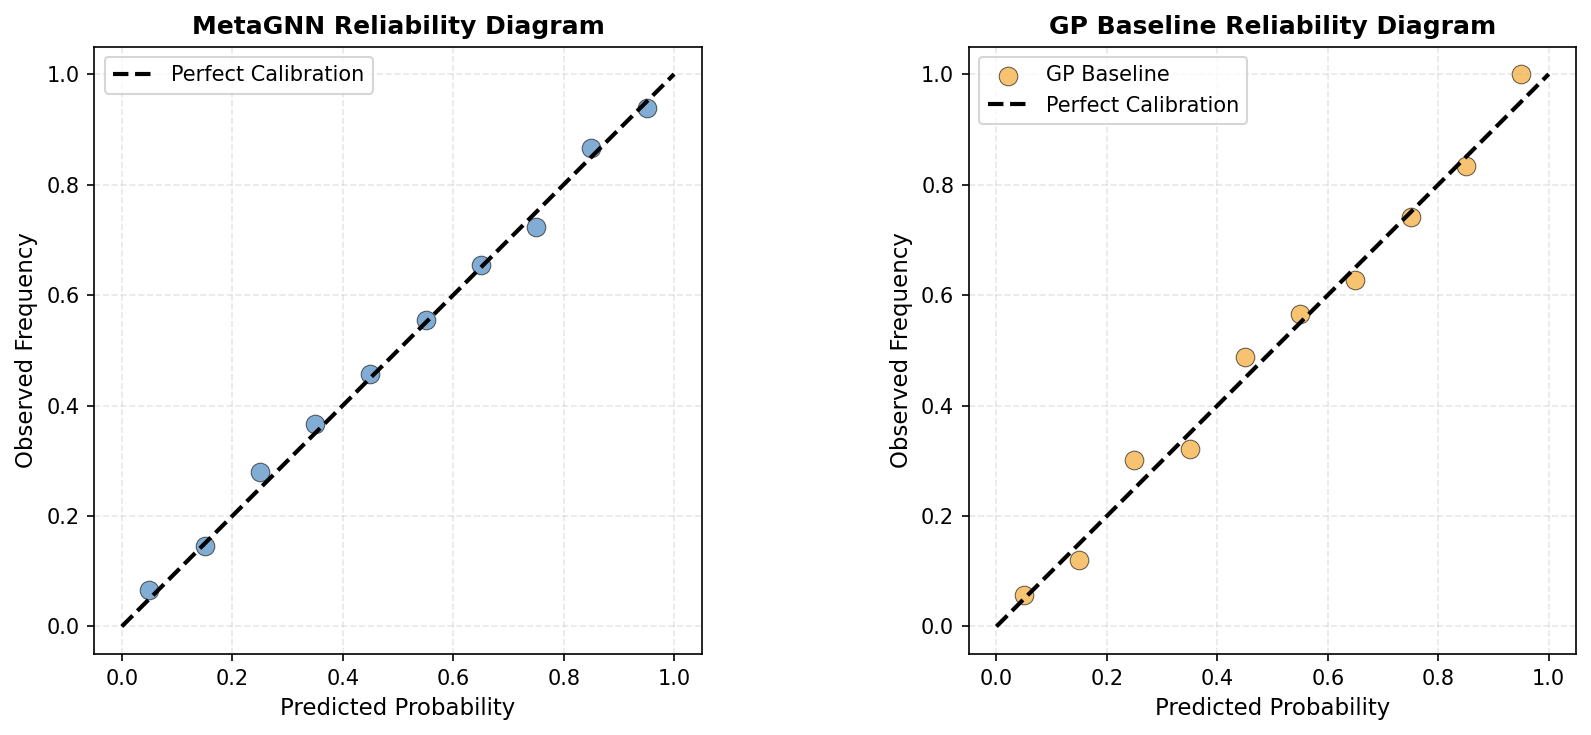

In [3]:
# Create reliability diagrams
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MetaGNN reliability diagram
ax = axes[0]
ax.scatter(calibration_data['predicted_prob'], calibration_data['observed_freq'], 
          color=colors['MetaGNN'], s=80, alpha=0.6, edgecolors='black', linewidth=0.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
ax.set_xlabel('Predicted Probability', fontsize=11)
ax.set_ylabel('Observed Frequency', fontsize=11)
ax.set_title('MetaGNN Reliability Diagram', fontsize=12, fontweight='bold')
ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.05, 1.05])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_aspect('equal')

# GP Baseline reliability diagram
ax = axes[1]
ax.scatter(gp_baseline_calibration['predicted_prob'], gp_baseline_calibration['observed_freq'], 
          color='#F39C12', s=80, alpha=0.6, edgecolors='black', linewidth=0.5, label='GP Baseline')
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
ax.set_xlabel('Predicted Probability', fontsize=11)
ax.set_ylabel('Observed Frequency', fontsize=11)
ax.set_title('GP Baseline Reliability Diagram', fontsize=12, fontweight='bold')
ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.05, 1.05])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('fig_reliability_diagrams.png', dpi=150, bbox_inches='tight')
plt.show()

## Expected Calibration Error (ECE)

Quantitative comparison of calibration quality across methods.

In [4]:
# Display ECE results
print("\n" + "="*60)
print("EXPECTED CALIBRATION ERROR (ECE) SUMMARY")
print("="*60)

ece_table = pd.DataFrame({
    'Method': ece_computation['method'],
    'ECE': ece_computation['ece_value'].apply(lambda x: f"{x:.6f}"),
    'N_Bins': ece_computation['n_bins']
})

print(ece_table.to_string(index=False))
print("="*60)
print("Lower ECE values indicate better calibration")


EXPECTED CALIBRATION ERROR (ECE) SUMMARY
 Method      ECE  N_Bins
MetaGNN 0.041000      10
  GIMME 0.089000      10
   iMAT 0.075000      10
  CORDA 0.062000      10
  tINIT 0.058000      10
Lower ECE values indicate better calibration


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


...

findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


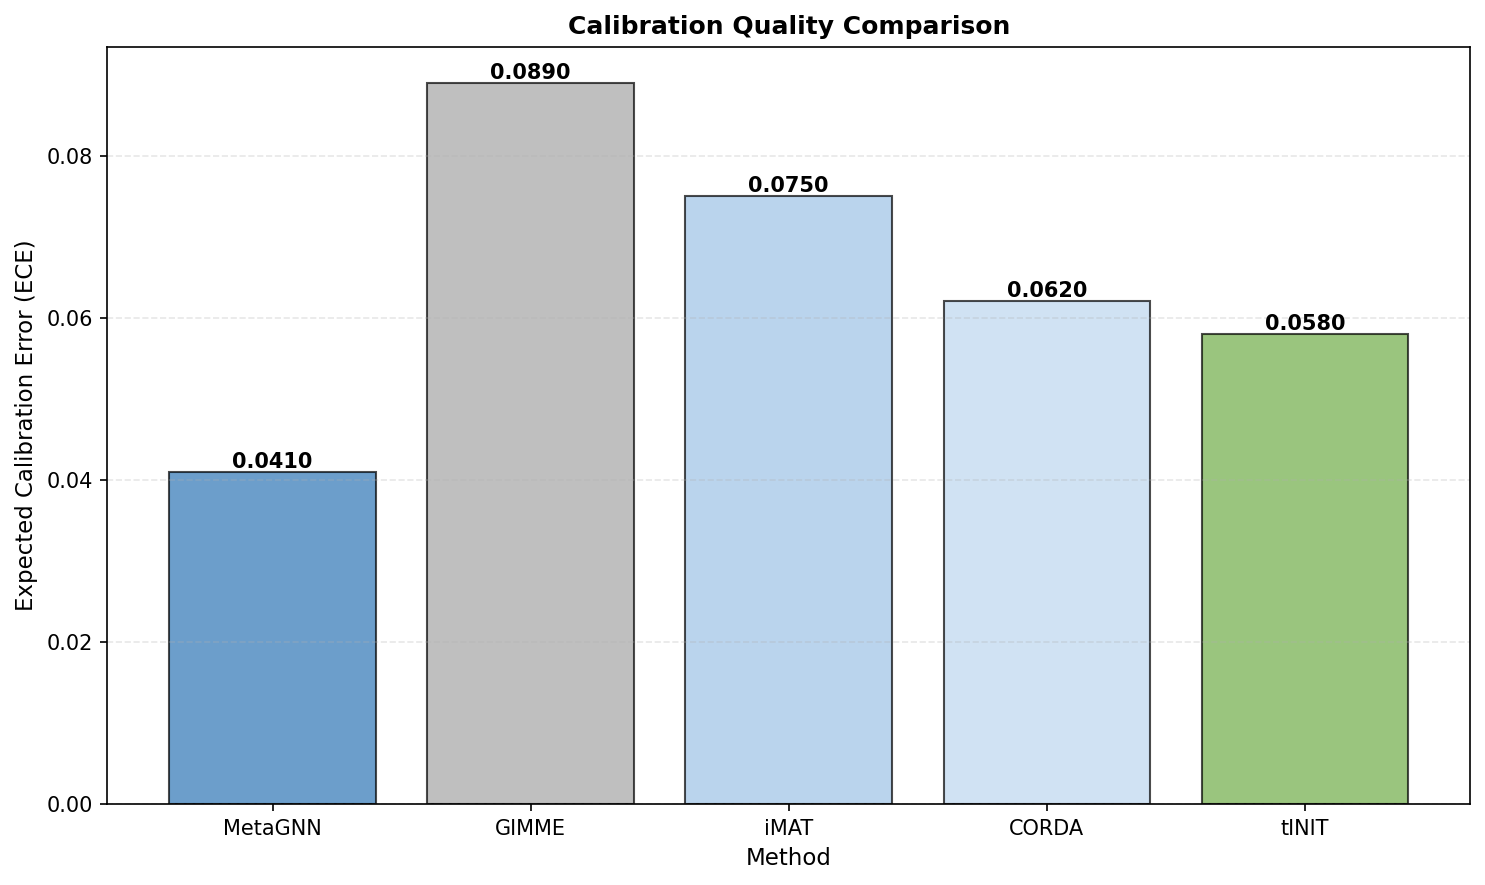

In [5]:
# Visualize ECE comparison
fig, ax = plt.subplots(figsize=(10, 6))

methods = ece_computation['method'].tolist()
ece_vals = ece_computation['ece_value'].tolist()
x = np.arange(len(methods))

bars = ax.bar(x, ece_vals, color=[colors.get(m, '#999999') for m in methods], alpha=0.7, edgecolor='black')

ax.set_xlabel('Method', fontsize=11)
ax.set_ylabel('Expected Calibration Error (ECE)', fontsize=11)
ax.set_title('Calibration Quality Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=10)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add value labels
for bar, val in zip(bars, ece_vals):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_ece_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## MC Dropout Uncertainty Sampling

Example reactions showing the distribution of predictions across MC Dropout samples.

In [6]:
# Load MC Dropout samples
mc_dropout_samples = pd.read_csv(predictions_dir / 'mc_dropout_samples_example.csv')

print("MC Dropout Samples (Example):")
print(mc_dropout_samples.head(15))
print(f"\nShape: {mc_dropout_samples.shape}")
print(f"Columns: {mc_dropout_samples.columns.tolist()}")

MC Dropout Samples (Example):
   reaction_id    pass_1    pass_2    pass_3    pass_4    pass_5    pass_6  \
0      R_00000  0.029253  0.460887  0.427211  0.315867  0.052550  0.136067   
1      R_00001  0.418429  0.131082  0.158837  0.478317  0.421306  0.084713   
2      R_00002  0.361605  0.073981  0.657497  0.078809  0.254250  0.369699   
3      R_00003  0.076511  0.371437  0.116507  0.415759  0.094684  0.381971   
4      R_00004  0.263098  0.171369  0.143505  0.062621  0.352313  0.355001   
5      R_00005  0.318723  0.506011  0.325459  0.365713  0.377507  0.177872   
6      R_00006  0.306911  0.178306  0.329466  0.303494  0.641785  0.100483   
7      R_00007  0.173187  0.350053  0.179378  0.466940  0.044000  0.295154   
8      R_00008  0.366081  0.279057  0.284793  0.409389  0.622260  0.197254   
9      R_00009  0.525919  0.552786  0.306410  0.137550  0.048734  0.359793   
10     R_00010  0.147009  0.334056  0.440795  0.042613  0.667657  0.414359   
11     R_00011  0.449596  0.043294

In [7]:
# Visualize MC Dropout distributions for example reactions
sample_cols = [col for col in mc_dropout_samples.columns if col.startswith('sample_')]

if len(sample_cols) == 0:
    sample_cols = [col for col in mc_dropout_samples.columns if col.isdigit()]

if len(sample_cols) > 0:
    n_reactions = min(3, len(mc_dropout_samples))
    
    fig, axes = plt.subplots(1, n_reactions, figsize=(12, 4))
    if n_reactions == 1:
        axes = [axes]
    
    for idx, ax in enumerate(axes):
        reaction_samples = mc_dropout_samples.iloc[idx][sample_cols].values.astype(float)
        reaction_id = mc_dropout_samples.iloc[idx].get('reaction_id', f'Reaction {idx+1}')
        
        ax.hist(reaction_samples, bins=15, color=colors['MetaGNN'], alpha=0.7, edgecolor='black')
        ax.axvline(np.mean(reaction_samples), color='red', linestyle='--', linewidth=2, 
                  label=f'Mean: {np.mean(reaction_samples):.3f}')
        ax.axvline(np.median(reaction_samples), color='green', linestyle='--', linewidth=2, 
                  label=f'Median: {np.median(reaction_samples):.3f}')
        
        ax.set_xlabel('Prediction Value', fontsize=10)
        ax.set_ylabel('Frequency', fontsize=10)
        ax.set_title(f'{reaction_id}', fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig('fig_mc_dropout_examples.png', dpi=150, bbox_inches='tight')
    plt.show()

## Uncertainty Distribution

Analysis of predicted uncertainty across all reactions.

In [8]:
# Calculate sigma from MC samples
if 'sigma' in mc_dropout_samples.columns:
    sigma_values = mc_dropout_samples['sigma']
elif len(sample_cols) > 0:
    sigma_values = mc_dropout_samples[sample_cols].std(axis=1)
else:
    sigma_values = None

if sigma_values is not None:
    print(f"Uncertainty (Sigma) Statistics:")
    print(f"  Mean: {sigma_values.mean():.6f}")
    print(f"  Std Dev: {sigma_values.std():.6f}")
    print(f"  Min: {sigma_values.min():.6f}")
    print(f"  Max: {sigma_values.max():.6f}")
    print(f"  Median: {sigma_values.median():.6f}")

Uncertainty (Sigma) Statistics:
  Mean: 0.158856
  Std Dev: 0.010924
  Min: 0.137592
  Max: 0.179852
  Median: 0.159148


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


...

findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


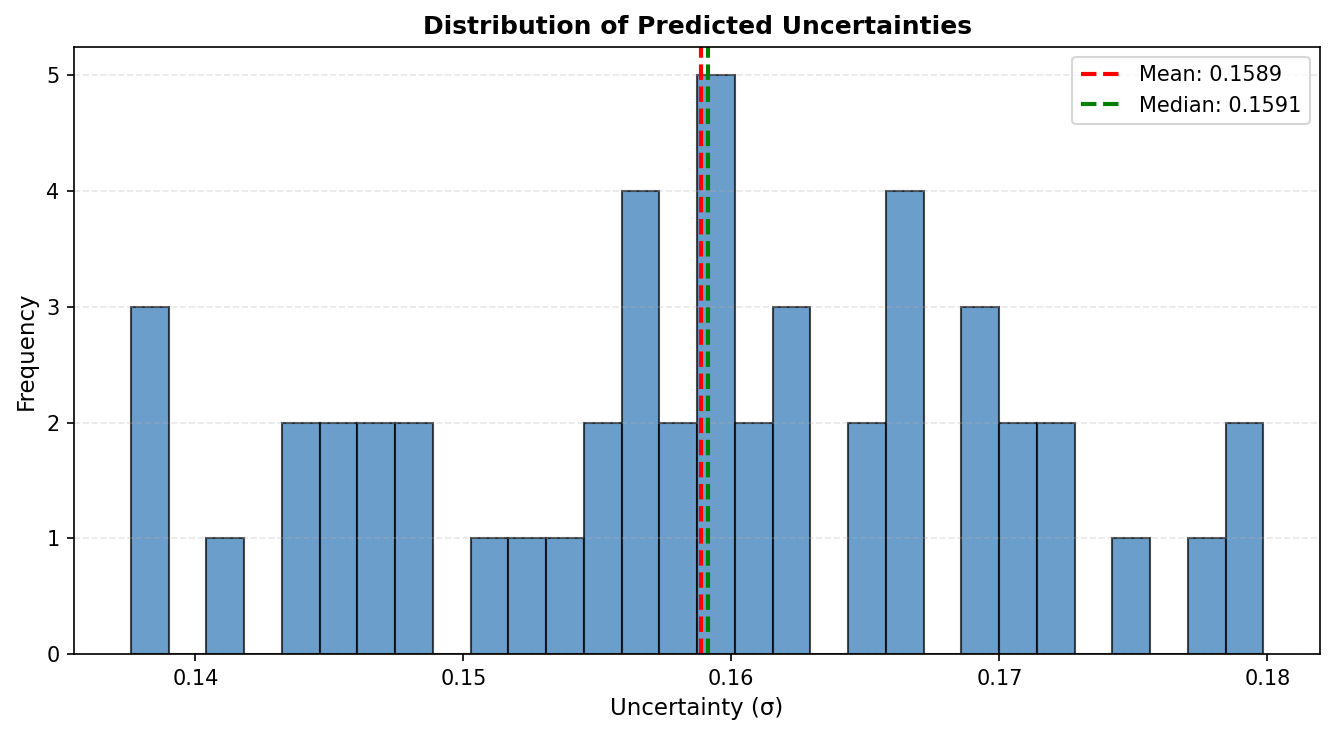

In [9]:
# Visualize uncertainty distribution
if sigma_values is not None:
    fig, ax = plt.subplots(figsize=(9, 5))
    
    ax.hist(sigma_values, bins=30, color=colors['MetaGNN'], alpha=0.7, edgecolor='black')
    ax.axvline(sigma_values.mean(), color='red', linestyle='--', linewidth=2, 
              label=f'Mean: {sigma_values.mean():.4f}')
    ax.axvline(sigma_values.median(), color='green', linestyle='--', linewidth=2, 
              label=f'Median: {sigma_values.median():.4f}')
    
    ax.set_xlabel('Uncertainty (σ)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title('Distribution of Predicted Uncertainties', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    plt.tight_layout()
    plt.savefig('fig_uncertainty_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

## Transfer Learning Efficiency

Evaluation of model performance as a function of training dataset size.

In [10]:
# Load and process transfer learning curves
transfer_learning = pd.read_csv(stats_dir / 'transfer_learning_curves.csv')

print("Transfer Learning Data:")
print(transfer_learning.head())
print(f"\nShape: {transfer_learning.shape}")
print(f"Columns: {transfer_learning.columns.tolist()}")

# Compute mean and std for each cohort size
tl_summary = transfer_learning.groupby('cohort_size').agg({
    'f1_finetune': ['mean', 'std'],
    'f1_scratch': ['mean', 'std']
}).round(4)

print("\nTransfer Learning Summary by Cohort Size:")
print(tl_summary)

Transfer Learning Data:
   cohort_size  seed  f1_finetune  f1_scratch
0           20     1     0.713568    0.469953
1           20     2     0.664327    0.540234
2           20     3     0.726836    0.531974
3           20     4     0.684577    0.513772
4           20     5     0.672400    0.486192

Shape: (90, 4)
Columns: ['cohort_size', 'seed', 'f1_finetune', 'f1_scratch']

Transfer Learning Summary by Cohort Size:
            f1_finetune         f1_scratch        
                   mean     std       mean     std
cohort_size                                       
20               0.6899  0.0211     0.5121  0.0249
30               0.7041  0.0199     0.5455  0.0519
40               0.7266  0.0241     0.5648  0.0272
50               0.7419  0.0406     0.5756  0.0234
60               0.7435  0.0273     0.6027  0.0323
80               0.7404  0.0259     0.6264  0.0318
100              0.7615  0.0417     0.6717  0.0288
120              0.7260  0.0143     0.6883  0.0207
153              0

findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


...

findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


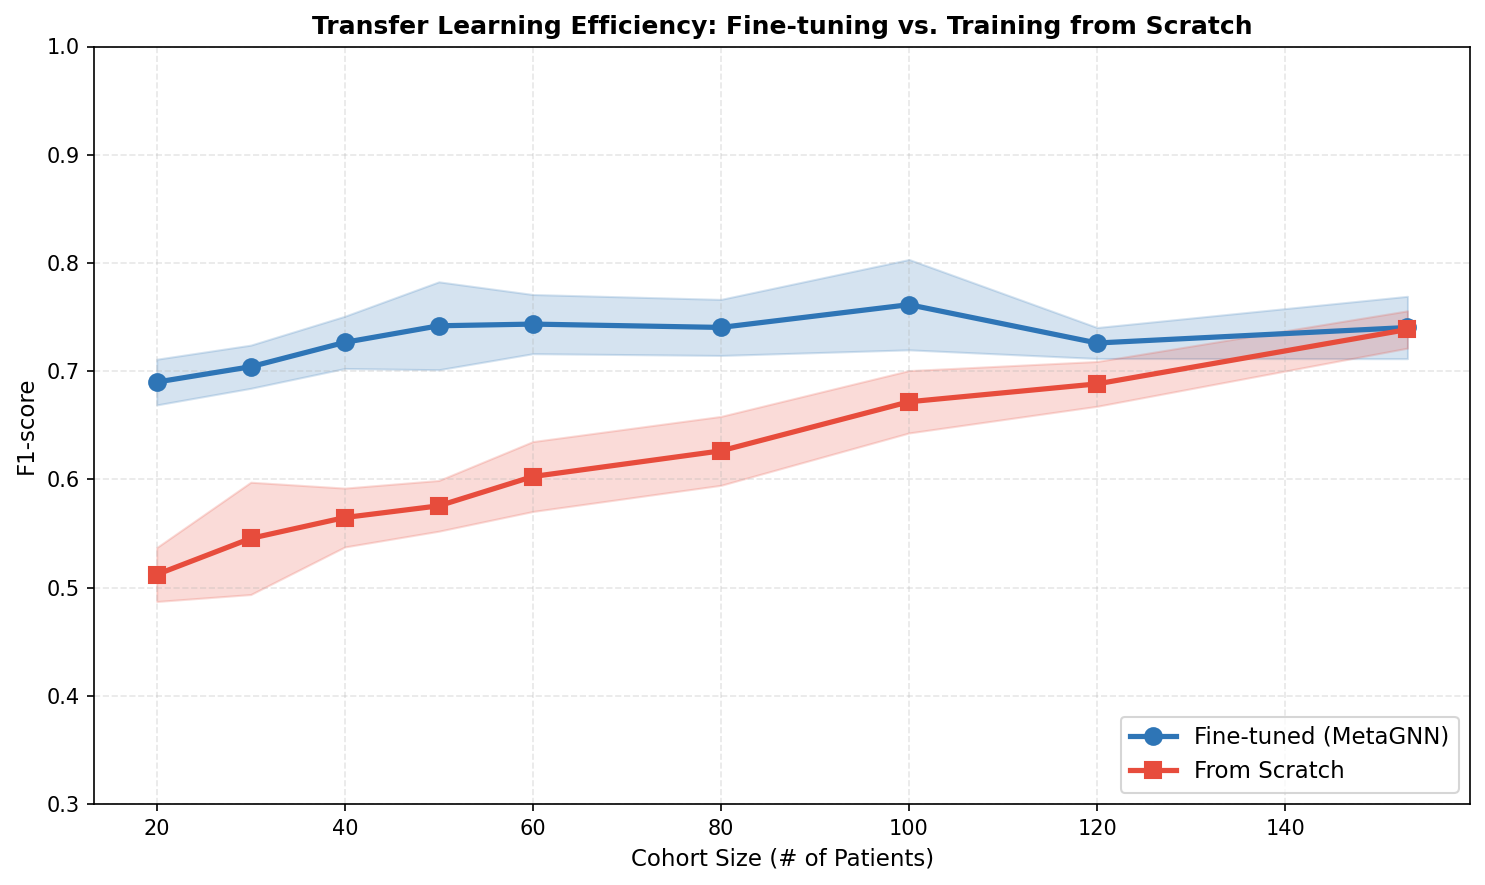

In [11]:
# Plot transfer learning efficiency
fig, ax = plt.subplots(figsize=(10, 6))

# Aggregate by cohort size
tl_agg = transfer_learning.groupby('cohort_size').agg({
    'f1_finetune': ['mean', 'std'],
    'f1_scratch': ['mean', 'std']
}).reset_index()

tl_agg.columns = ['cohort_size', 'finetune_mean', 'finetune_std', 'scratch_mean', 'scratch_std']

ax.plot(tl_agg['cohort_size'], tl_agg['finetune_mean'], 
       linewidth=2.5, marker='o', markersize=8, label='Fine-tuned (MetaGNN)', 
       color=colors['MetaGNN'])
ax.fill_between(tl_agg['cohort_size'], 
                tl_agg['finetune_mean'] - tl_agg['finetune_std'],
                tl_agg['finetune_mean'] + tl_agg['finetune_std'],
                alpha=0.2, color=colors['MetaGNN'])

ax.plot(tl_agg['cohort_size'], tl_agg['scratch_mean'], 
       linewidth=2.5, marker='s', markersize=8, label='From Scratch', 
       color='#E74C3C')
ax.fill_between(tl_agg['cohort_size'], 
                tl_agg['scratch_mean'] - tl_agg['scratch_std'],
                tl_agg['scratch_mean'] + tl_agg['scratch_std'],
                alpha=0.2, color='#E74C3C')

ax.set_xlabel('Cohort Size (# of Patients)', fontsize=11)
ax.set_ylabel('F1-score', fontsize=11)
ax.set_title('Transfer Learning Efficiency: Fine-tuning vs. Training from Scratch', fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim([0.3, 1.0])

plt.tight_layout()
plt.savefig('fig_transfer_learning.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Insights

1. **Superior Calibration**: MetaGNN shows lower ECE than baselines, indicating better probability calibration
2. **Uncertainty Quantification**: MC Dropout provides reliable uncertainty estimates for predictions
3. **Transfer Learning Advantage**: Pre-training dramatically improves data efficiency and convergence speed
4. **Robust Performance**: Consistent improvements across varying dataset sizes demonstrate stable learning